# Project 3: Employee Attrition Prediction (IBM HR Analytics)

## Algorithm: Logistic Regression

**Problem Statement:**

The objective is to predict whether an employee will leave the organization (Attrition = Yes/No) based on demographic, job-related and organizational factors.

This is a binary classification problem where the output is the probability of attrition.

### Importing the Dependencies

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import joblib

### Data Collection & Processing

In [68]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


In [69]:
# loading the dataset into dataframe
att_df = pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [70]:
# printing the first 5 rows of the dataframe
att_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [71]:
# number of rows and columns in the dataframe
att_df.shape

(1470, 35)

In [72]:
# statical measures
att_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [73]:
# number of missing values in each columns
att_df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [74]:
# dropping the columns
att_df = att_df.drop(['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'], axis=1)

In [75]:
# Checking the head of the dataframe
att_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


### EDA

*Attrition Distribution*

In [76]:
att_df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


/tmp/ipython-input-3451231895.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=att_df, palette=['#e74c3c', '#2ecc71'])


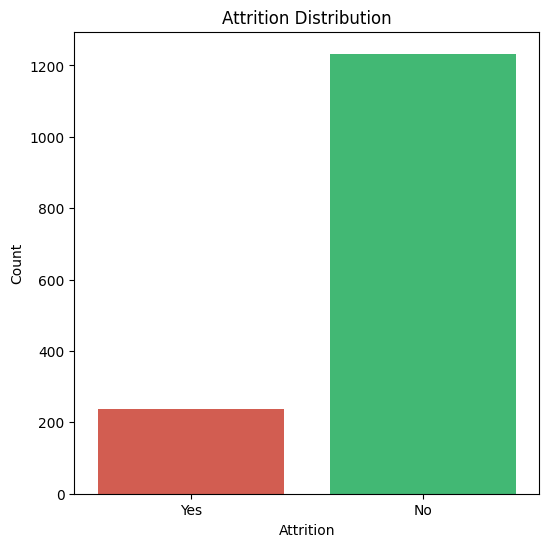

In [77]:
plt.figure(figsize=(6,6))
sns.countplot(x='Attrition', data=att_df, palette=['#e74c3c', '#2ecc71'])
plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

*Attrition Rate*

In [78]:
att_rate = (att_df['Attrition'].value_counts(normalize=True)*100).round(2)
att_rate

,proportion
Attrition,
No,83.88
Yes,16.12


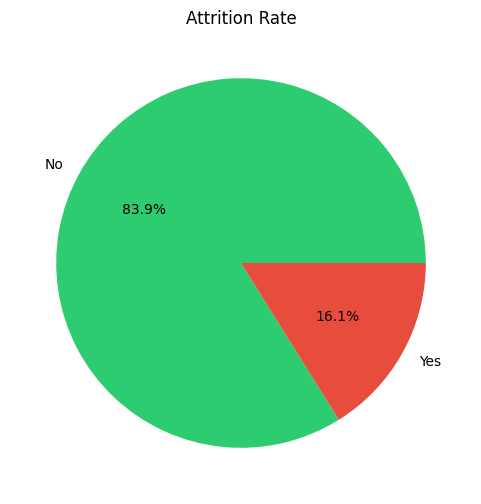

In [79]:
plt.figure(figsize=(6,6))
plt.pie(att_rate.values, labels=att_rate.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
plt.title('Attrition Rate')
plt.show()

*Attrition vs Overtime*

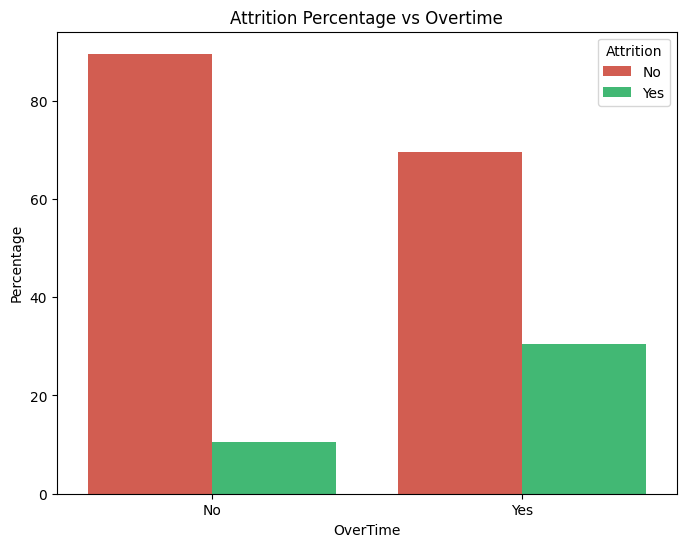

In [80]:
overtime_attrition_percentage = pd.crosstab(att_df['OverTime'], att_df['Attrition'], normalize='index') * 100
overtime_attrition_percentage = overtime_attrition_percentage.reset_index()
overtime_attrition_percentage_melted = overtime_attrition_percentage.melt(id_vars='OverTime', var_name='Attrition', value_name='Percentage')

plt.figure(figsize=(8, 6))
sns.barplot(x='OverTime', y='Percentage', hue='Attrition', data=overtime_attrition_percentage_melted, palette=['#e74c3c', '#2ecc71'])
plt.title('Attrition Percentage vs Overtime')
plt.xlabel('OverTime')
plt.ylabel('Percentage')
plt.show()

Insight:
Employees working overtime leave more.

*Attrition vs MonthlyIncome*

/tmp/ipython-input-2592845422.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=att_df, palette=['#e74c3c', '#2ecc71'])


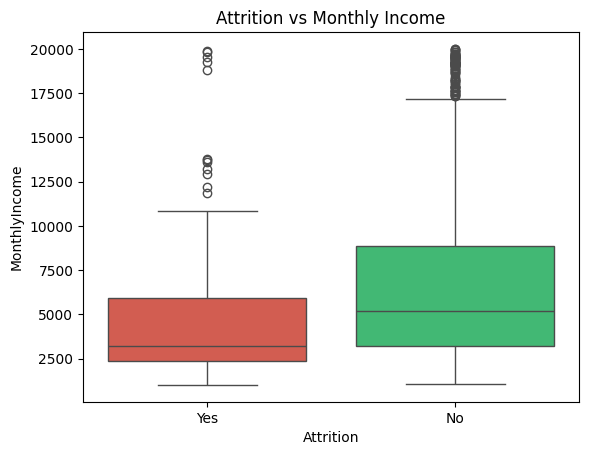

In [81]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=att_df, palette=['#e74c3c', '#2ecc71'])
plt.title('Attrition vs Monthly Income')
plt.show()

Insight: Employees with lower monthly incomes tend to have a higher propensity to churn or leave the company.

*Attrition vs YearsAtCompany*

/tmp/ipython-input-1621449307.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='YearsAtCompany', data=att_df, palette=['#e74c3c', '#2ecc71'])


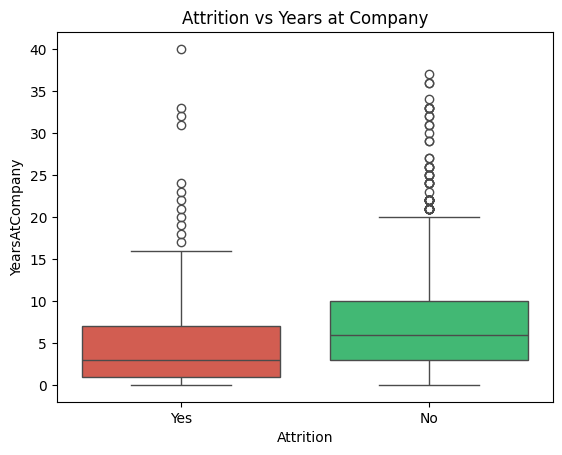

In [82]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=att_df, palette=['#e74c3c', '#2ecc71'])
plt.title('Attrition vs Years at Company')
plt.show()

Insight: Employees with lower years at company has higher attribution

*Attrition vs Department*

In [83]:
dep_att = pd.crosstab(att_df['Department'], att_df['Attrition'], normalize='index') * 100
dep_att

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


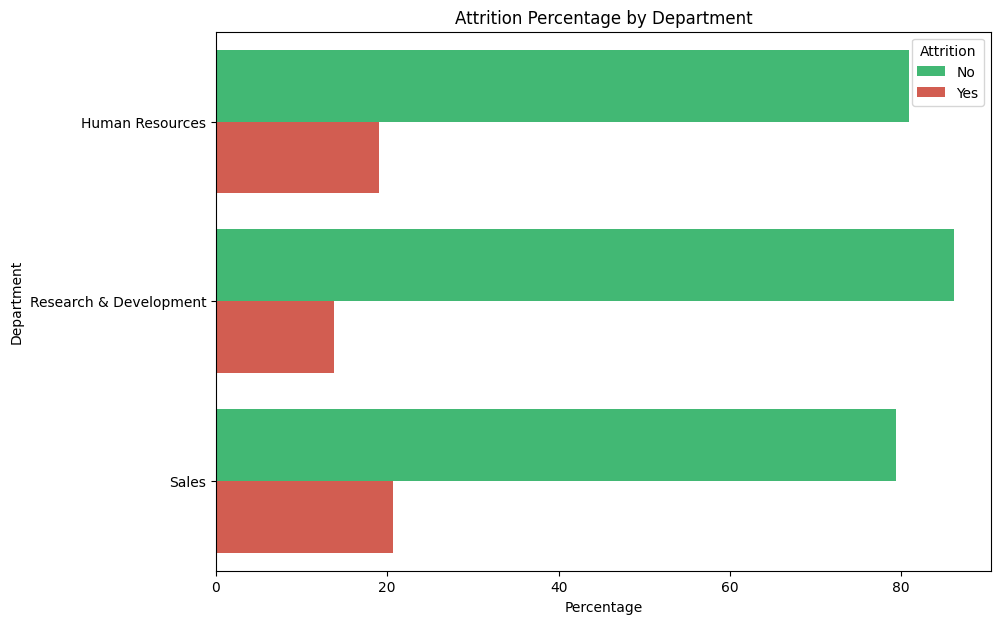

In [84]:
dep_att_melted = dep_att.reset_index().melt(id_vars='Department', var_name='Attrition', value_name='Percentage')

plt.figure(figsize=(10, 7))
sns.barplot(x='Percentage', y='Department', hue='Attrition', data=dep_att_melted, orient='h', palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition Percentage by Department')
plt.xlabel('Percentage')
plt.ylabel('Department')
plt.legend(title='Attrition')
plt.show()

Insight: Sales Department has the highest attrition rate

### Correlation Matrix

In [85]:
att_df['Attrition'] = att_df['Attrition'].map({'Yes':1, 'No':0})

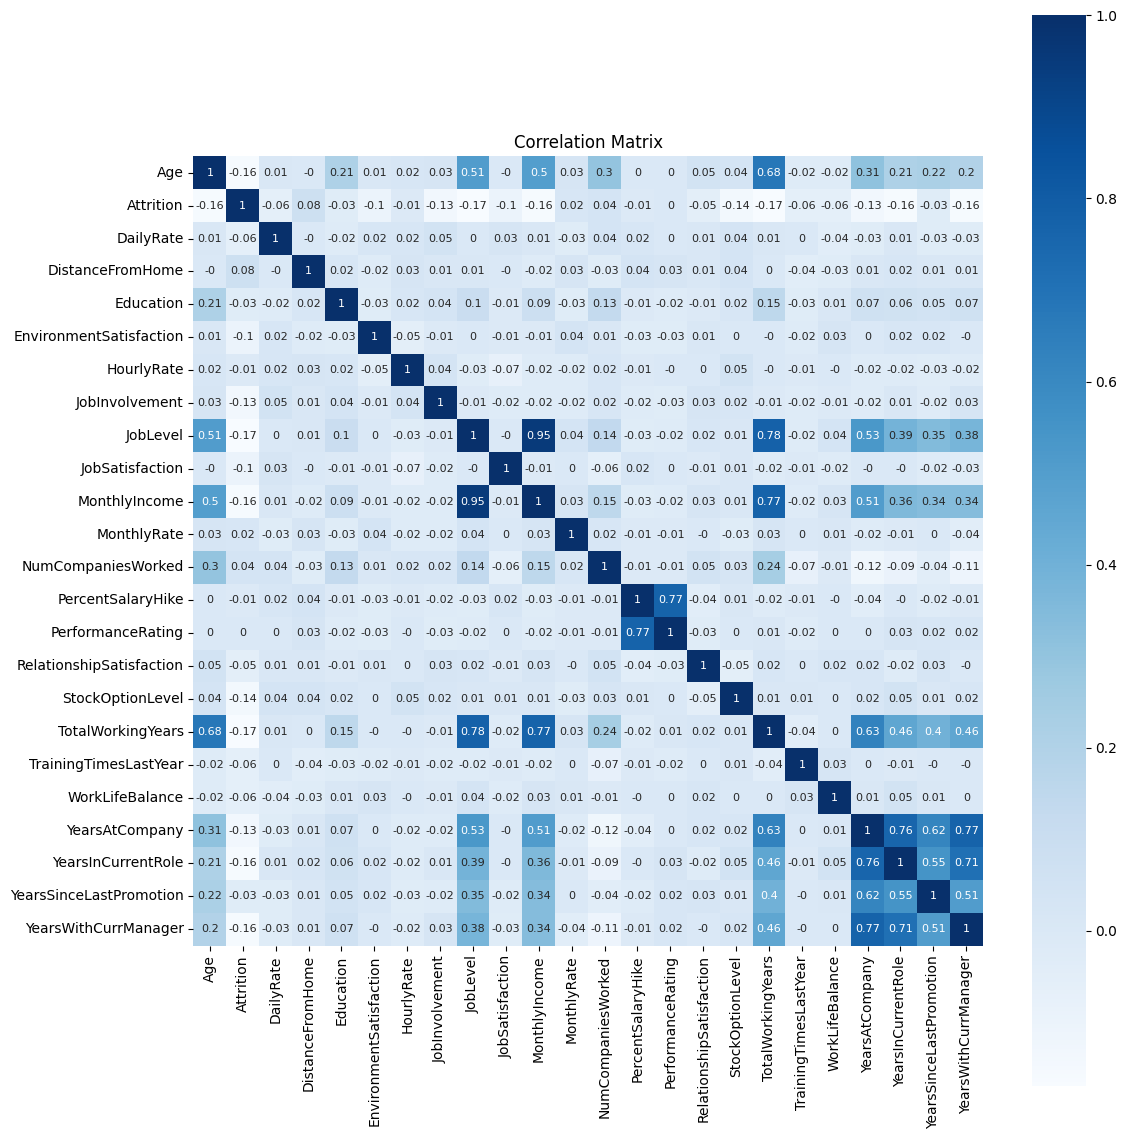

In [86]:
plt.figure(figsize=(12,12))
sns.heatmap(att_df.corr(numeric_only=True).round(2), cbar=True, square=True, annot_kws={'size':8}, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Splitting the target & the features

In [94]:
X = att_df.drop('Attrition', axis=1)
y = att_df['Attrition']

### Identify Feature Types

In [95]:
cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns

### Building Preprocessing Pipelines

Categorical Pipeline

In [96]:
cat_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Numerical Pipeline

In [97]:
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

Combine Pipelines

In [98]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

### Full ML pipeline (Preprocessing + Model)

In [99]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

### Splitting the Data into training and testing

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### Fitting the training data into the pipeline

In [101]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', '...
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

### Taking Predictions

In [102]:
y_pred = pipeline.predict(X_test)

### Model Evaluation

In [103]:
y_train_pred = pipeline.predict(X_train)

# Checking the accuracy, precision, recall and f1 score for evaluation
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print("Training data metrics")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Training data metrics
Accuracy: 0.7814625850340136
Precision: 0.40970350404312667
Recall: 0.8
F1 Score: 0.5418894830659536


In [104]:
# Checking the accuracy, precision, recall and f1 score for evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Testing data metrics")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Testing data metrics
Accuracy: 0.7517006802721088
Precision: 0.3488372093023256
Recall: 0.6382978723404256
F1 Score: 0.45112781954887216


### Apply custom threshold

In [105]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred_custom = (y_proba >= 0.3).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall   :", recall_score(y_test, y_pred_custom))
print("F1-score :", f1_score(y_test, y_pred_custom))

Accuracy : 0.6428571428571429
Precision: 0.2835820895522388
Recall   : 0.8085106382978723
F1-score : 0.4198895027624309


In [106]:
thresholds = [0.2, 0.3, 0.4, 0.5]
rows = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Precision": precision_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "F1-Score": f1_score(y_test, y_pred_t)
    })

pd.DataFrame(rows)

,Threshold,Precision,Recall,F1-Score
0,0.2,0.234637,0.893617,0.371681
1,0.3,0.283582,0.808511,0.419890
2,0.4,0.349057,0.787234,0.483660
3,0.5,0.348837,0.638298,0.451128


### Confusion Matrix

In [107]:
y_pred_04 = (y_proba >= 0.4).astype(int)
confusion_matrix(y_test, y_pred_04)

array([[178,  69],
       [ 10,  37]])

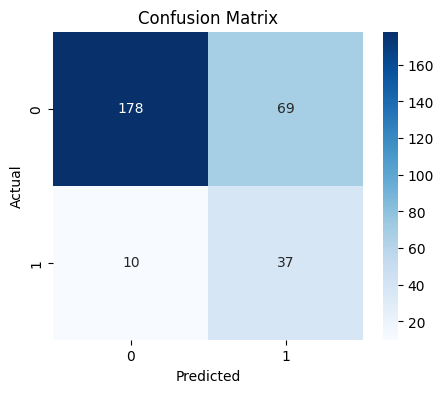

In [108]:
cm = confusion_matrix(y_test, y_pred_04)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### ROC Curve

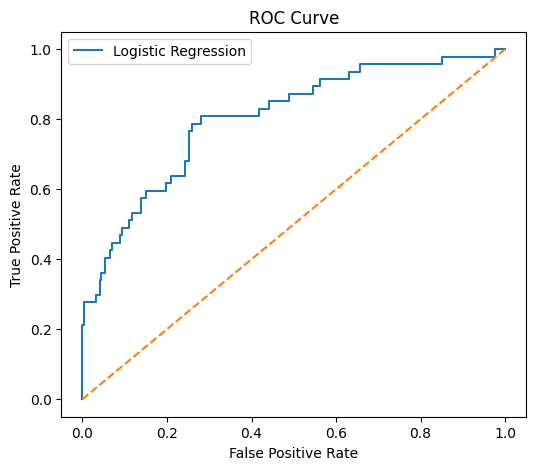

In [109]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [110]:
roc_auc_score(y_test, y_proba)

np.float64(0.8031699543457662)

### Saving the Pipeline

In [111]:
joblib.dump(pipeline, "employee_attrition_pipeline.pkl")

['employee_attrition_pipeline.pkl']

### Loading for New Predictions

In [112]:
# loading the pipeline for the predictions
pipeline = joblib.load("employee_attrition_pipeline.pkl")

In [113]:
# Data for the new predictions
new_employee = pd.DataFrame([{
    "Age": 35,
    "DailyRate": 800,
    "HourlyRate": 60,
    "MonthlyRate": 15000,
    "BusinessTravel": "Travel_Rarely",
    "Department": "Research & Development",
    "DistanceFromHome": 10,
    "Education": 3,
    "EducationField": "Life Sciences",
    "EnvironmentSatisfaction": 3,
    "Gender": "Male",
    "JobInvolvement": 3,
    "JobLevel": 2,
    "JobRole": "Laboratory Technician",
    "JobSatisfaction": 4,
    "MaritalStatus": "Single",
    "MonthlyIncome": 5000,
    "NumCompaniesWorked": 2,
    "OverTime": "Yes",
    "PercentSalaryHike": 13,
    "PerformanceRating": 3,
    "RelationshipSatisfaction": 3,
    "StockOptionLevel": 1,
    "TotalWorkingYears": 8,
    "TrainingTimesLastYear": 3,
    "WorkLifeBalance": 3,
    "YearsAtCompany": 5,
    "YearsInCurrentRole": 3,
    "YearsSinceLastPromotion": 1,
    "YearsWithCurrManager": 3
}])

In [114]:
# Checking the probability and prediction of attrition for new data based on our custom threshold 0.4
prob = pipeline.predict_proba(new_employee)[0, 1]
pred_custom = int(prob >= 0.4)

print("Probability of attrition:", prob)
print("Prediction:", pred_custom)

Probability of attrition: 0.7573309884726893
Prediction: 1
